# Import Libraries

In [394]:
import sys
import json
import joblib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Plotting style
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# Load and Explore Dataset

In [395]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name.lower() == "notebooks"
    else CURRENT_DIR
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"

for folder in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

possible_paths = [
    PROJECT_ROOT / "data" / "raw" / "aug_train.csv",
    PROJECT_ROOT / "data" / "aug_train.csv",
    PROJECT_ROOT / "aug_train.csv",
    CURRENT_DIR / "aug_train.csv",
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    found_files = list(PROJECT_ROOT.rglob("aug_train.csv"))
    if found_files:
        DATA_PATH = found_files[0]

if DATA_PATH is None or not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find 'aug_train.csv' inside: {PROJECT_ROOT}\n"
        f"Make sure the file is located inside data/raw/."
    )

print(f"Found dataset at: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import add_engineered_features, MODEL_EXCLUDED_COLUMNS
from src.modeling import RANDOM_STATE, build_models, calculate_metrics

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Found dataset at: d:\Data & AI\Microsoft ML Engineer\ITI AI Level 1\Graduation Project\Recruitment-Assistant-System\data\raw\aug_train.csv
Dataset Shape: (19158, 14)
Columns: ['enrollee_id', 'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


# Check Missing Values and Target Distribution

In [396]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check target distribution
print("\nTarget Distribution:")
print(df["target"].value_counts())
print("\nTarget Percentage (%):")
print((df["target"].value_counts(normalize=True) * 100).round(2))

Missing values in each column:
enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

Target Distribution:
target
0.0    14381
1.0     4777
Name: count, dtype: int64

Target Percentage (%):
target
0.0    75.07
1.0    24.93
Name: proportion, dtype: float64


# Data Preprocessing & Feature Engineering

In [397]:
# Separate raw features and target
X_raw = df.drop(columns=["target"]).copy()
y = df["target"].astype(int).copy()

# Apply domain-specific feature engineering from src/preprocessing.py
X_features = add_engineered_features(X_raw)

# Drop non-predictive and sensitive columns (enrollee_id, city, gender)
X = X_features.drop(columns=MODEL_EXCLUDED_COLUMNS, errors="ignore").copy()

print("Engineered features created successfully.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nFeature Columns (18 total):")
print(X.columns.tolist())
X.head()

Engineered features created successfully.
Features shape: (19158, 18)
Target shape: (19158,)

Feature Columns (18 total):
['city_development_index', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'experience_years', 'training_hours_log', 'training_intensity', 'is_company_missing', 'is_company_type_missing', 'cdi_x_experience', 'experience_job_ratio', 'is_low_cdi']


,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,experience_years,training_hours_log,training_intensity,is_company_missing,is_company_type_missing,cdi_x_experience,experience_job_ratio,is_low_cdi
0,0.920,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,21.0,3.610918,1.636364,1.0,1.0,20.240,11.000000,0.0
1,0.776,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,15.0,3.871201,2.937500,0.0,0.0,12.416,2.666667,0.0
2,0.624,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,5.0,4.430817,13.833333,1.0,1.0,3.744,6.000000,1.0
3,0.789,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,0.0,3.970292,52.000000,1.0,0.0,0.789,1.000000,0.0
4,0.767,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,21.0,2.197225,0.363636,0.0,0.0,16.874,4.400000,0.0


# EDA

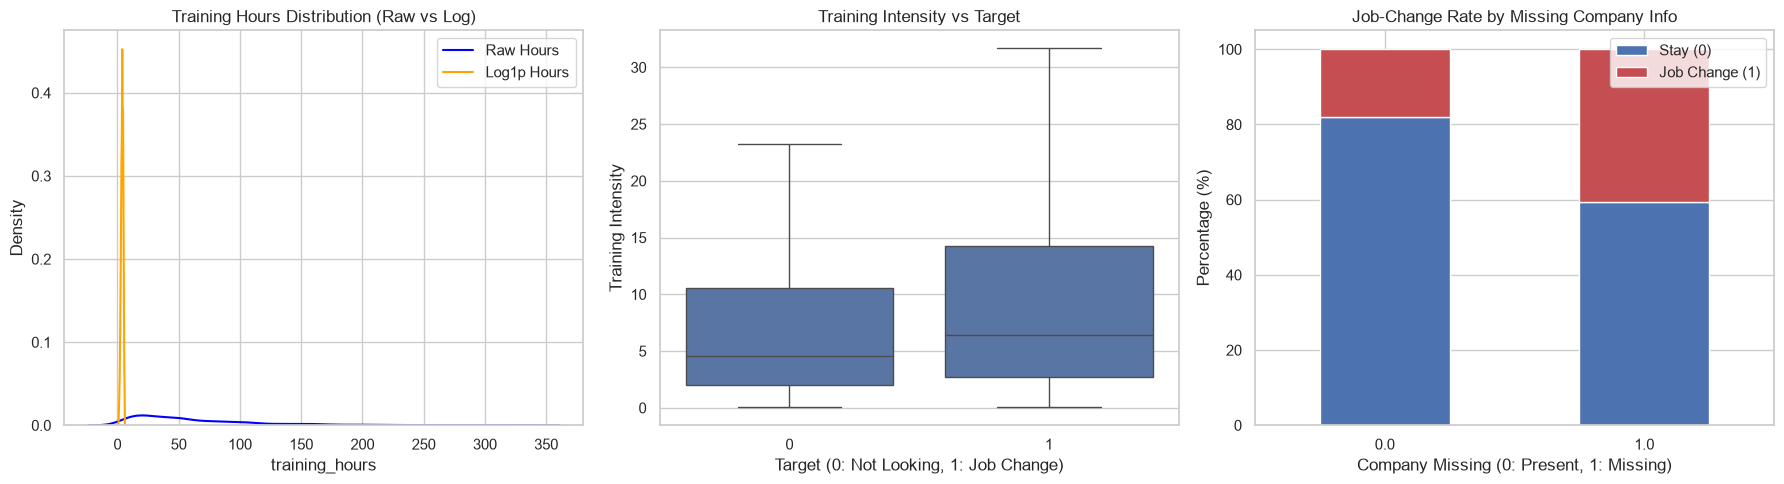

In [398]:
# Exploratory Analysis for Engineered Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Comparison of raw training hours vs log-transformed training hours
sns.kdeplot(data=X_features, x="training_hours", label="Raw Hours", ax=axes[0], color="blue")
sns.kdeplot(data=X_features, x="training_hours_log", label="Log1p Hours", ax=axes[0], color="orange")
axes[0].set_title("Training Hours Distribution (Raw vs Log)")
axes[0].legend()

# 2. Boxplot of training intensity grouped by target
temp_eda_df = X_features.copy()
temp_eda_df["target"] = y
sns.boxplot(data=temp_eda_df, x="target", y="training_intensity", ax=axes[1], showfliers=False)
axes[1].set_title("Training Intensity vs Target")
axes[1].set_xlabel("Target (0: Not Looking, 1: Job Change)")
axes[1].set_ylabel("Training Intensity")

# 3. Bar chart showing job-change rate when company info is missing vs present
company_missing_target = pd.crosstab(
    X_features["is_company_missing"], y, normalize="index"
) * 100
company_missing_target.plot(kind="bar", stacked=True, ax=axes[2], color=["#4c72b0", "#c44e52"])
axes[2].set_title("Job-Change Rate by Missing Company Info")
axes[2].set_xlabel("Company Missing (0: Present, 1: Missing)")
axes[2].set_ylabel("Percentage (%)")
axes[2].legend(["Stay (0)", "Job Change (1)"])
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "engineered_features_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

# Define Features and Target

In [399]:
# Verify defined features and target variable
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (19158, 18)
Target shape (y): (19158,)


# Train-Test Split

In [400]:
# Split the data into 80% training and 20% testing sets
# stratify=y preserves the 75:25 class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

X_train shape: (15326, 18)
X_test shape:  (3832, 18)

Train target distribution:
target
0    0.7506
1    0.2494
Name: proportion, dtype: float64

Test target distribution:
target
0    0.7508
1    0.2492
Name: proportion, dtype: float64


# Training Logistic Regression Model

In [401]:
import importlib
import src.modeling
importlib.reload(src.modeling)

from src.modeling import build_models
# Build complete ML pipelines (handling imputation, encoding, and scaling inside)
lr_pipeline, rf_pipeline, xgb_pipeline = build_models(scale_pos_weight=2.0)

# Train Logistic Regression Pipeline on training data
lr_pipeline.fit(X_train, y_train)

# Make predictions and calculate probabilities on test data
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Training Complete.")

Logistic Regression Training Complete.


# Confusion Matrix Heatmap for Logistic Regression

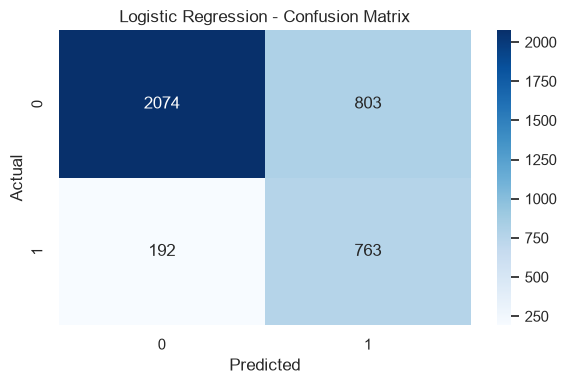

In [402]:
# Plot Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# Training Random Forest Classifier

In [403]:
# Train Random Forest Pipeline on training data
rf_pipeline.fit(X_train, y_train)

# Make predictions and calculate probabilities on test data
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Training Complete.")

Random Forest Training Complete.


# Confusion Matrix Heatmap for Random Forest

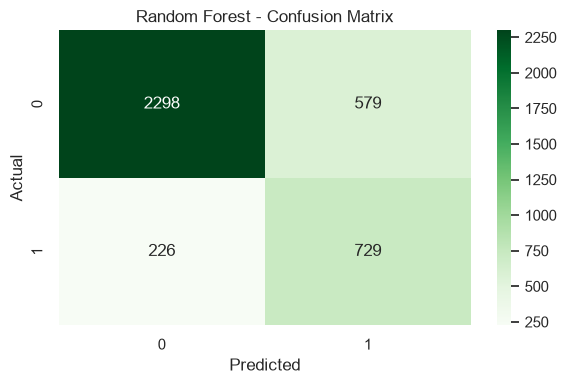

In [404]:
# Plot Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# Training XGBoost Classifier (Gradient Boosting)

In [405]:
from xgboost import XGBClassifier

xgb_preprocessor = clone(rf_pipeline.named_steps["preprocessor"])

ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

xgb_pipeline = Pipeline([
    ("preprocessor", xgb_preprocessor),
    ("model", XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.08,
        scale_pos_weight=ratio,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost Training Complete.")

XGBoost Training Complete.


# Confusion Matrix Heatmap for XGBoost

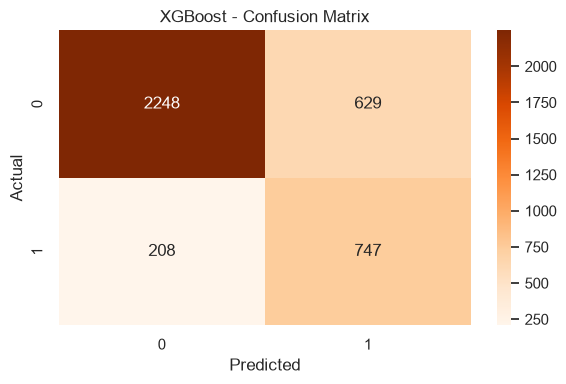

In [406]:

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

# Threshold Optimization

In [407]:
def find_best_threshold(y_true, y_probs, metric="f1"):
    best_thresh = 0.50
    best_score = 0.0
    thresholds = np.linspace(0.40, 0.70, 31)
    
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        if metric == "f1":
            score = f1_score(y_true, preds, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, preds, zero_division=0)
            
        if score > best_score:
            best_score = score
            best_thresh = t
            
    return round(best_thresh, 2), round(best_score, 4)

thresh_lr, f1_lr = find_best_threshold(y_test, y_prob_lr)
thresh_rf, f1_rf = find_best_threshold(y_test, y_prob_rf)
thresh_xgb, f1_xgb = find_best_threshold(y_test, y_prob_xgb)

print(f"Optimal Thresholds (Max F1):")
print(f"Logistic Regression: {thresh_lr} (F1: {f1_lr})")
print(f"Random Forest:       {thresh_rf} (F1: {f1_rf})")
print(f"XGBoost:             {thresh_xgb} (F1: {f1_xgb})")

y_pred_lr_tuned = (y_prob_lr >= thresh_lr).astype(int)
y_pred_rf_tuned = (y_prob_rf >= thresh_rf).astype(int)
y_pred_xgb_tuned = (y_prob_xgb >= thresh_xgb).astype(int)

Optimal Thresholds (Max F1):
Logistic Regression: 0.54 (F1: 0.6066)
Random Forest:       0.49 (F1: 0.6448)
XGBoost:             0.59 (F1: 0.648)


# Models Evaluations

In [408]:
# Evaluate Logistic Regression
print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr, digits=4))
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"Logistic Regression ROC-AUC Score: {auc_lr:.4f}")

# Evaluate Random Forest
print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, digits=4))
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest ROC-AUC Score: {auc_rf:.4f}")

# Evaluate XGBoost
print("\n=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred_xgb, digits=4))
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"XGBoost ROC-AUC Score: {auc_xgb:.4f}")

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0     0.9153    0.7209    0.8065      2877
           1     0.4872    0.7990    0.6053       955

    accuracy                         0.7403      3832
   macro avg     0.7012    0.7599    0.7059      3832
weighted avg     0.8086    0.7403    0.7564      3832

Logistic Regression ROC-AUC Score: 0.8008

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0     0.9105    0.7987    0.8510      2877
           1     0.5573    0.7634    0.6443       955

    accuracy                         0.7899      3832
   macro avg     0.7339    0.7810    0.7476      3832
weighted avg     0.8225    0.7899    0.7994      3832

Random Forest ROC-AUC Score: 0.8148

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0     0.9153    0.7814    0.8431      2877
           1     0.5429  

# Compare ROC Curves

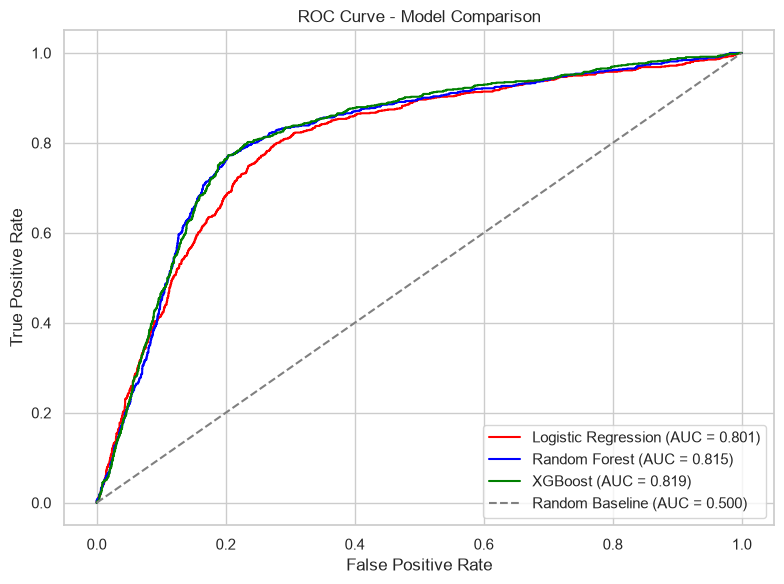

In [409]:
# Calculate ROC curve values for all three models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Plot ROC curves comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", color="red")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})",color="blue")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})", color="green")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curve_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# Random Forest Feature Importance

Top 10 Predictive Features:
                   Feature  Importance
0   city_development_index    0.262460
1               is_low_cdi    0.165626
2       is_company_missing    0.122498
3  is_company_type_missing    0.081076
4         cdi_x_experience    0.078694
5          education_level    0.040742
6             company_size    0.034754
7         experience_years    0.029126
8     experience_job_ratio    0.026915
9       training_intensity    0.026245


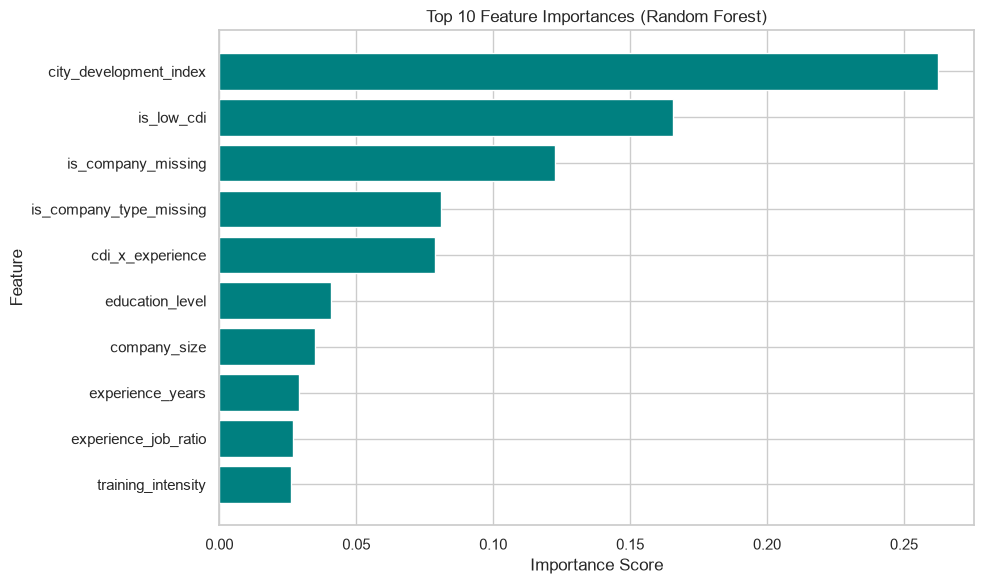

In [410]:
# Extract feature importances from Random Forest model inside the pipeline
rf_model = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 10 Predictive Features:")
print(feature_importance.head(10))

# Save feature importance to results
feature_importance.to_csv(RESULTS_DIR / "top_predictive_features.csv", index=False)

# Plot horizontal bar chart
top_features = feature_importance.head(10).sort_values("Importance", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="teal")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_predictive_features.png", dpi=200, bbox_inches="tight")
plt.show()

# Models Summary

In [411]:
metrics_summary = pd.DataFrame({
    "Logistic Regression": calculate_metrics(y_test, y_pred_lr, y_prob_lr),
    "Random Forest": calculate_metrics(y_test, y_pred_rf, y_prob_rf),
    "XGBoost": calculate_metrics(y_test, y_pred_xgb, y_prob_xgb),
}).T

metrics_summary.index.name = "Model"
metrics_summary = metrics_summary.round(4)

print("=== Models Metrics Summary ===\n")
print(metrics_summary)

# Majority-class baseline accuracy
majority_class = int(y_train.mode()[0])
baseline_pred = np.full(len(y_test), majority_class)
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"\nMajority-class baseline accuracy: {baseline_acc:.4f}")

=== Models Metrics Summary ===

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7403     0.4872  0.7990    0.6053   0.8008
Random Forest          0.7899     0.5573  0.7634    0.6443   0.8148
XGBoost                0.7816     0.5429  0.7822    0.6409   0.8189

Majority-class baseline accuracy: 0.7508


# Top 10 Candidate Ranking

In [412]:
# Rank test candidates by predicted probability of job-change intention
ranking_columns = [
    "enrollee_id",
    "education_level",
    "experience",
    "company_type",
    "training_hours",
    "city_development_index",
]
available_cols = [c for c in ranking_columns if c in df.columns]

ranking_df = df.loc[X_test.index, available_cols].copy()
ranking_df["Job_Change_Probability"] = y_prob_xgb
ranking_df["Job_Change_Percentage"] = (y_prob_rf * 100).round(2)

# Sort candidates descending by probability
ranking_df = ranking_df.sort_values("Job_Change_Probability", ascending=False).reset_index(drop=True)
ranking_df.insert(0, "Rank", range(1, len(ranking_df) + 1))

# Save top 10 recommended candidates
top_10 = ranking_df.head(10).copy()
top_10.to_csv(RESULTS_DIR / "top_10_recommended_candidates.csv", index=False)

print("Top 10 Candidates by Predicted Job-Change Intention:")
print(top_10)

Top 10 Candidates by Predicted Job-Change Intention:
   Rank  enrollee_id education_level experience   company_type  \
0     1        31227        Graduate          4        Pvt Ltd   
1     2         6838         Masters          7        Pvt Ltd   
2     3         5845        Graduate         <1  Public Sector   
3     4        27436         Masters          1            NaN   
4     5        19759        Graduate          1            NaN   
5     6        18454        Graduate          1            NaN   
6     7         5165         Masters          3        Pvt Ltd   
7     8         6539        Graduate          1        Pvt Ltd   
8     9        13527        Graduate          2            NaN   
9    10        10515        Graduate          3        Pvt Ltd   

   training_hours  city_development_index  Job_Change_Probability  \
0             298                   0.624                0.926434   
1             284                   0.624                0.924864   
2            

# Save Model Artifacts

In [ ]:
# 1. Save benchmark metrics for Dashboard and FastAPI
metrics_summary.to_csv(RESULTS_DIR / "models_benchmark_metrics.csv")

# 2. Select and save the best pipeline dynamically
best_model_name = metrics_summary.sort_values(["F1 Score", "ROC-AUC"], ascending=False).index[0]

if best_model_name == "XGBoost":
    best_pipeline = xgb_pipeline
elif best_model_name == "Random Forest":
    best_pipeline = rf_pipeline
else:
    best_pipeline = lr_pipeline

joblib.dump(lr_pipeline, MODELS_DIR / "recruitment_logistic_regression.pkl")
joblib.dump(rf_pipeline, MODELS_DIR / "recruitment_random_forest.pkl")
joblib.dump(xgb_pipeline, MODELS_DIR / "recruitment_xgboost.pkl")
joblib.dump(best_pipeline, MODELS_DIR / "best_recruitment_pipeline.pkl")
joblib.dump(best_pipeline.named_steps["preprocessor"], MODELS_DIR / "preprocessor_pipeline.pkl")

# 3. Save cleaned candidates data
cleaned_candidates = df.copy()

for col in ["city_development_index", "training_hours"]:
    median_val = X_train[col].median() if col in X_train.columns else df[col].median()
    cleaned_candidates[col] = cleaned_candidates[col].fillna(median_val)

cat_columns = [
    "gender", "enrolled_university", "education_level", "major_discipline",
    "experience", "company_size", "company_type", "last_new_job"
]

for col in cat_columns:
    if col in X_train.columns:
        mode_series = X_train[col].mode(dropna=True)
    elif col in df.columns:
        mode_series = df[col].mode(dropna=True)
    else:
        mode_series = []
        
    mode_val = mode_series.iloc[0] if len(mode_series) else "Unknown"
    cleaned_candidates[col] = cleaned_candidates[col].fillna(mode_val)

cleaned_candidates.to_csv(PROCESSED_DIR / "cleaned_candidates.csv", index=False)

# 4. Save metadata JSON
metadata = {
    "best_model": best_model_name,
    "selection_metric": "F1 Score",
    "optimal_threshold": float(thresh_xgb),
    "target_definition": {
        "0": "Not looking for a job change",
        "1": "Looking for a job change"
    },
    "excluded_from_model": MODEL_EXCLUDED_COLUMNS,
    "random_state": RANDOM_STATE
}

with open(MODELS_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("ALL PROJECT ARTIFACTS AND MODELS SAVED SUCCESSFULLY!")
print(f"Primary Selected Model: {best_model_name}")
print(f"Models directory:    {MODELS_DIR}")
print(f"Results directory:   {RESULTS_DIR}")
print(f"Figures directory:   {FIGURES_DIR}")
print(f"Processed directory: {PROCESSED_DIR}")

ALL PROJECT ARTIFACTS AND MODELS SAVED SUCCESSFULLY!
Primary Selected Model: Random Forest
Models directory:    d:\Data & AI\Microsoft ML Engineer\ITI AI Level 1\Graduation Project\Recruitment-Assistant-System\models
Results directory:   d:\Data & AI\Microsoft ML Engineer\ITI AI Level 1\Graduation Project\Recruitment-Assistant-System\outputs\results
Figures directory:   d:\Data & AI\Microsoft ML Engineer\ITI AI Level 1\Graduation Project\Recruitment-Assistant-System\outputs\figures
Processed directory: d:\Data & AI\Microsoft ML Engineer\ITI AI Level 1\Graduation Project\Recruitment-Assistant-System\data\processed
